<a href="https://colab.research.google.com/github/Brunoxue/hsi_examples/blob/main/sklearn_classification_university_of_pavia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://huggingface.co/datasets/danaroth/pavia

fatal: destination path 'pavia' already exists and is not an empty directory.


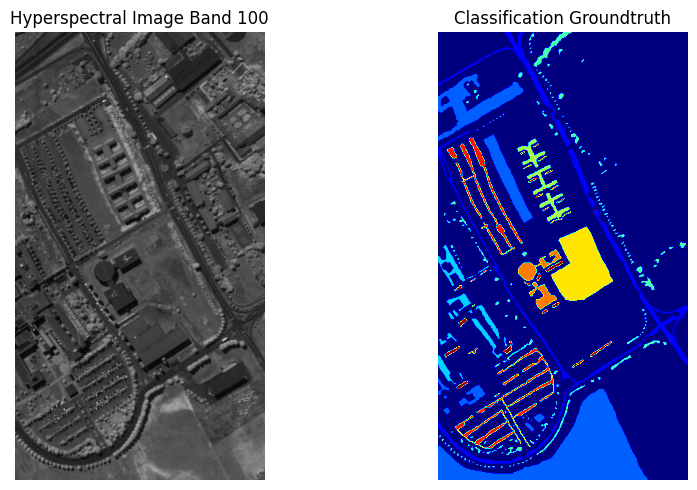

In [ ]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np

# Load the hyperspectral data
hsi = loadmat('pavia/PaviaU.mat')['paviaU'].astype(float)
GT = loadmat('pavia/PaviaU_gt.mat')['paviaU_gt'].astype(float)

fig, axs = plt.subplots(1, 2, figsize=(10, 5), tight_layout=True)
axs[0].imshow(hsi[:, :, 100], cmap='gray')
axs[0].axis('off')
axs[0].set_title('Hyperspectral Image Band 100')

# Plot the spectrum
axs[1].imshow(GT, cmap='jet')
axs[1].axis('off')
axs[1].set_title('Classification Groundtruth')

plt.show()

In [ ]:
# Generate Samples for Training and Testing
(x,y,L)=hsi.shape
N=x*y

hsi=np.reshape(hsi,(N,L))
GT=np.reshape(GT,(N,))

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(hsi[GT!=0,:], GT[GT!=0], train_size = 0.05, random_state=0)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, recall_score, precision_score
import pandas as pd

# Evaluation of classifiers
def classification_evaluation(y_test, y_predict, n_class=9):
  recall=recall_score(y_test, y_predict, average=None) * 100
  precision=precision_score(y_test, y_predict, average=None) * 100
  OA=accuracy_score(y_test, y_predict) * 100
  AA=recall_score(y_test, y_predict, average="macro") * 100

  # Create a dataframe to display the metrics
  metrics_df = pd.DataFrame({
      'Recall (%)': recall,
      'Precision (%)': precision,
      '# of Test Samples': [np.sum(y_test==i+1) for i in range(n_class)],
      '# of Train Samples': [np.sum(y_train==i+1) for i in range(n_class)],
  })

  metrics_df.reset_index()
  metrics_df.index = metrics_df.index + 1

  pd.options.display.precision = 2

  print(metrics_df.to_string())

  metrics_image_df = pd.DataFrame({
      'values': [OA, AA],
      }, index=(['OA(%)','AA(%)']))

  print(metrics_image_df.to_string(header=False))
  return {"recall":recall, "precision":precision, "OA":OA, "AA":AA}


# Support Vector Machine (SVM)

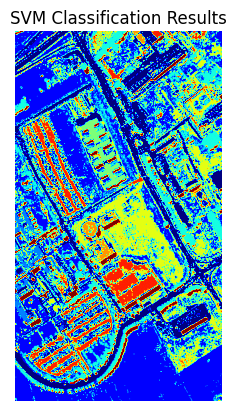

   Recall (%)  Precision (%)  # of Test Samples  # of Train Samples
1       92.85          93.76               6308                 323
2       98.28          95.44              17694                 955
3       79.70          84.54               1990                 109
4       92.05          97.75               2920                 144
5       98.83          99.53               1287                  58
6       85.33          93.82               4784                 245
7       86.72          84.16               1250                  80
8       90.51          85.07               3500                 182
9       99.89         100.00                905                  42
OA(%)  93.58
AA(%)  91.57


In [ ]:
# Support Vector Machine Classification
from sklearn.svm import SVC

pipe_svm = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svc', SVC())
    ])

param_svm = [
    {'svc__C': 10.0**np.arange(-2,5,1), 'svc__gamma': 10.0**np.arange(-3,3,1), 'svc__kernel': ['rbf']},
    ]

clf = GridSearchCV(pipe_svm, param_svm)
clf.fit(X_train, y_train)

y_predict_svm = clf.best_estimator_.predict(X_test)

results_svm = clf.best_estimator_.predict(hsi)
results_svm = np.reshape(results_svm,(x,y))

plt.figure()
plt.imshow(results_svm, cmap='jet')
plt.axis('off')
plt.title('SVM Classification Results')
plt.show()

performance_svm = classification_evaluation(y_test, y_predict_svm)

## Random Forest (RF)

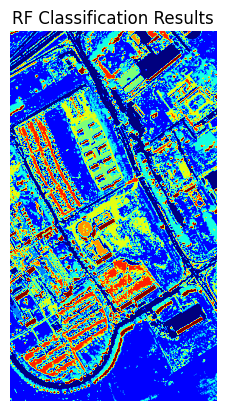

   Recall (%)  Precision (%)  # of Test Samples  # of Train Samples
1       90.42          92.13               6308                 323
2       97.07          87.55              17694                 955
3       65.63          75.19               1990                 109
4       86.99          92.70               2920                 144
5       97.59          98.36               1287                  58
6       54.95          87.55               4784                 245
7       82.32          80.45               1250                  80
8       86.71          77.92               3500                 182
9       99.01          99.78                905                  42
OA(%)  87.53
AA(%)  84.52


In [ ]:
# Random Forest Classification
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ('scaler', MinMaxScaler()),
    ('rf', RandomForestClassifier(n_estimators=500, oob_score=True))
    ])

pipe_rf.fit(X_train, y_train)
y_predict_rf = pipe_rf.predict(X_test)

results_rf = pipe_rf.predict(hsi)
results_rf = np.reshape(results_rf,(x,y))

plt.figure()
plt.imshow(results_rf, cmap='jet')
plt.axis('off')
plt.title('RF Classification Results')
plt.show()

performance_rf = classification_evaluation(y_test, y_predict_rf)

# Neural Network Classification

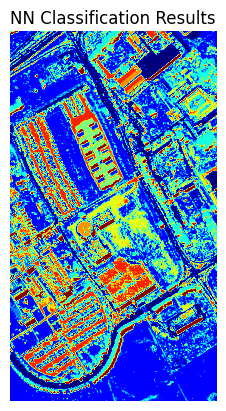

   Recall (%)  Precision (%)  # of Test Samples  # of Train Samples
1       84.45          92.48               6308                 323
2       96.36          88.68              17694                 955
3       48.34          69.76               1990                 109
4       84.62          86.95               2920                 144
5       98.60          99.69               1287                  58
6       61.68          89.86               4784                 245
7       74.96          67.60               1250                  80
8       91.20          69.66               3500                 182
9       99.89          99.89                905                  42
OA(%)  86.28
AA(%)  82.23


In [ ]:
# Neural Network
from sklearn.neural_network import MLPClassifier

pipe_nn = Pipeline([
    ('scaler', MinMaxScaler()),
    ('nn', MLPClassifier(solver='adam', hidden_layer_sizes=(20), random_state=1, batch_size=20, max_iter=1000, learning_rate_init=0.001))
    ])

pipe_nn.fit(X_train, y_train)
y_predict_nn = pipe_nn.predict(X_test)

results_nn = pipe_nn.predict(hsi)
results_nn = np.reshape(results_nn,(x,y))

plt.figure()
plt.imshow(results_nn, cmap='jet')
plt.axis('off')
plt.title('NN Classification Results')
plt.show()

performance_svm = classification_evaluation(y_test, y_predict_nn)